# Introduction to Data Science – Homework 6
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Due: Friday, Feburary 28 2025, 11:59pm.

In Part 1 of this homework you will scrape github repositories and organize the information in a Pandas dataframe. In Part 2, you will use linear regression to gain meaningful insights. 

## Your Data
First Name: Abby(YiChun)
<br>
Last Name: Chen
<br>
E-mail:u1583033@utah.edu
<br>
UID:u1583033
<br>

In [1]:
# imports and setup 
from bs4 import BeautifulSoup

import pandas as pd
import scipy as sc
import numpy as np

import statsmodels.formula.api as sm

import matplotlib.pyplot as plt 
plt.style.use('ggplot')
%matplotlib inline  
plt.rcParams['figure.figsize'] = (10, 6) 
# where the data is stored
DATA_PATH = "snapshots"

### 1. Scrape Github Repository List using BeautifulSoup
In this part you will explore Github repositories, specifically the 100 most-starred repositories. You are going to scrape data from a snapshot of [this repository list](https://github.com/search?o=desc&q=stars%3A%3E1&s=stars&type=Repositories).

### 1.1. Check whether you are permitted to scrape the data
Before you start to scrape any website you should go through the terms of service and policy documents of the website. Almost all websites post conditions to use their data. Check the terms of [https://github.com/](https://github.com/) (see the tiny "terms" link at the bottom of the page) to see whether the site permits you to scrape their data or not. Are you sure you are allowed to scrape?

**Your solution:**
TODO

We are able to access the data through automated mean for training or developing machine learning. However, by this would also give "free pass" to the Github from accessing our data. 

Reference solution: The [terms of service](https://help.github.com/articles/github-terms-of-service/) do not mention scraping, but the [help pages on the site policy](https://help.github.com/en/github/site-policy/github-acceptable-use-policies#5-scraping-and-api-usage-restrictionsyou) allows scraping. You can scrape Github under the following conditions:

- Researchers may scrape public, non-personal information from GitHub for research purposes, only if any publications resulting from that research are open access.
- Archivists may scrape GitHub for public data for archival purposes.
- You may not scrape GitHub for spamming purposes, including for the purposes of selling GitHub users' personal information, such as to recruiters, headhunters, and job boards.

The [robots.txt](https://github.com/robots.txt) is a little less explicit about what is allowed and what not, but overall, since we are scraping Github pages for education/research purposes and not publishing the results, it is reasonable to assume that this is ok to do.

### Task 1.2 Load the Data

To avoid any problems with GitHub blocking us from downloading the data many times, we have downloaded and saved a snapshot of the html files for you in the [snapshots](snapshots) folder. Note that the snapshots folder is not completely consistent with what you see on the web – we've made a few patches to the data that makes your task here easier and this data represents a snapshot in time. You will be treating the data folder as your website to be scraped. The path to data folder is stored in `DATA_PATH` variable.

In the data folder you will find first 10 pages of highly starred repositories saved as `search_page_1.html`,`search_page_2.html`,`search_page_3.html` ... `search_page_10.html`

Check out page 5 if you want to see what happens if you scrape too quickly 😉. **Tip**: you should skip page 5.

Now read these html files in python and create a soup object. This is a two step process:
 * Read the text in the html files
 * Create the soup from the files that you've read. 

In [2]:
# Creating the soup
## Your code goes here
import os

all_soups = []
for i in range(1,11): # read in the first 10 pages as required
    if i == 5: # skip page 5
        continue
    file_name = f"search_page_{i}.html" # saved the repositories as formatted
    file_path = os.path.join(DATA_PATH,file_name)

    with open(file_path,"r",encoding="utf-8") as file:
        content = file.read()

    soup_obj = BeautifulSoup(content,"html.parser")
    all_soups.append(soup_obj)

all_soups[1]

<!DOCTYPE html>

<!-- saved from url=(0077)https://github.com/search?o=desc&q=stars%3A%3E1&s=stars&type=Repositories&p=2 -->
<html data-a11y-animated-images="system" data-a11y-link-underlines="true" data-color-mode="auto" data-dark-theme="dark" data-light-theme="light" data-turbo-loaded="" lang="en"><head><meta content="text/html; charset=utf-8" http-equiv="Content-Type"/><style type="text/css">.turbo-progress-bar {
  position: fixed;
  display: block;
  top: 0;
  left: 0;
  height: 3px;
  background: #0076ff;
  z-index: 2147483647;
  transition:
    width 300ms ease-out,
    opacity 150ms 150ms ease-in;
  transform: translate3d(0, 0, 0);
}
</style>
<link href="https://github.githubassets.com/" rel="dns-prefetch"/>
<link href="https://avatars.githubusercontent.com/" rel="dns-prefetch"/>
<link href="https://github-cloud.s3.amazonaws.com/" rel="dns-prefetch"/>
<link href="https://user-images.githubusercontent.com/" rel="dns-prefetch"/>
<link crossorigin="" href="https://github.githubasse

### Extracting Data

Extract the following data for each repository, and create a Pandas Dataframe with a row for each repository and a column for each of these datums. 

+ The name of the repository
+ The primary language (there are multiple or none, if multiple, use the first one, if none, use "none")
+ The number of watching
+ The number of stars
+ The number of forks
+ The number of issues
+ Number of commits
+ Number of pull requests, and

Here's an example for one repository, `freeCodeCamp/freeCodeCamp,` in our dataset: 
```python
{'name': 'freeCodeCamp',
'language': 'TypeScript',
'watching': '8500',
'stars': '410251',
'forks': '39007',
'issues': 168,
'commits': 37591,
'pull_requests':66
}
```

### Task 1.3 Extract repository URLs

If you look at the results of the 100 most-starred repositories [(this list)](https://github.com/search?o=desc&q=stars%3A%3E1&s=stars&type=Repositories), you will notice that all the information we want to extract for each repository is not in that list. This information is in the repository’s individual web page, for example [996icu](https://github.com/996icu/996.ICU). 

Therefore, you will first have to extract links of each repository from the soup you scraped earlier. When you extract the link for the repository, it will be a path to the stored HTML page for the repository. You will use this path to read the file and extract the above information.

Refer to the scraping lecture for details on how to do this. We recommend you use the web inspector to identify the relevant structures.

Example of a link that you need to extract - `996icu/996.ICU.html`. This means in the next task you need to access local folder `snapshots/996icu/996.ICU.html`. Similarly, for `521xueweihan/HelloGitHub.html` you should access `snapshots/521xueweihan/HelloGitHub.html` 

You may need to do string operations to get the desired format for the link. For example, if you get `raw_link = https://github.com/996icu/996.ICU`, you can do
`link = raw_link.replace("https://github.com/", "") + ".html"` so you get `996icu/996.ICU.html`.

Please title your output 'repo_list', and print this list once you have created it.

In [10]:
import json

repo_list = []

for soup in all_soups:
    
    script_tag = soup.find('script', {'data-target': 'react-app.embeddedData'}) # name of the repositories
    
    if script_tag:
        data = json.loads(script_tag.string)
        results = data.get('payload', {}).get('results', [])
        
        for item in results:
            repo_name = item.get('hl_name') 
            
            if repo_name:
                link = repo_name + ".html"
                repo_list.append(link)
print(len(repo_list))
print(repo_list)

90
['freeCodeCamp/freeCodeCamp.html', 'EbookFoundation/free-programming-books.html', 'sindresorhus/awesome.html', 'codecrafters-io/build-your-own-x.html', 'public-apis/public-apis.html', 'jwasham/coding-interview-university.html', 'kamranahmedse/developer-roadmap.html', 'donnemartin/system-design-primer.html', '996icu/996.ICU.html', 'vinta/awesome-python.html', 'freeCodeCamp/freeCodeCamp.html', 'EbookFoundation/free-programming-books.html', 'sindresorhus/awesome.html', 'codecrafters-io/build-your-own-x.html', 'public-apis/public-apis.html', 'jwasham/coding-interview-university.html', 'kamranahmedse/developer-roadmap.html', 'donnemartin/system-design-primer.html', '996icu/996.ICU.html', 'vinta/awesome-python.html', 'freeCodeCamp/freeCodeCamp.html', 'EbookFoundation/free-programming-books.html', 'sindresorhus/awesome.html', 'codecrafters-io/build-your-own-x.html', 'public-apis/public-apis.html', 'jwasham/coding-interview-university.html', 'kamranahmedse/developer-roadmap.html', 'donnemar

### Task 1.4 Extracting required information

Once you have extracted links for each repository, you can start parsing those HTML pages using BeautifulSoup and extract all the required information.

**Note**: There are few repositories which do not contain 'issues' field (such as 996icu/996.ICU.html). Therefore, write your code such that it handles this condition as well.

**Save the dataframe you created to a new file project_info.csv and include this in your submission.** This separate file will also be graded and is required to earn points.

You also need to make sure that you reformat all numerical columns to be integer data. You can do that either as you parse, or when you have a dataframe with strings.

Some repositories (~30) are missing in the collection, we have provided code to skip these cases, and similarly in the next frame to NOT include the None numbers in the storage.

**Tips**: the exact value of stars and forks can be found on top right corner, with mouse hover over the value. E.g., hover over 410k, shows 410,246. For *watching*, the data is abbreviated, You need to manually convert it. For example, 8.5k should be converted to 8500.

In [65]:
from pathlib import Path
from bs4 import BeautifulSoup
import pandas as pd

def number(text):
    text = str(text).lower().replace(',', '').strip()
    if 'k' in text:
        return int(float(text.replace('k', '')) * 1000)
    if 'm' in text:
        return int(float(text.replace('m', '')) * 1000000)
    else:
        return int(text)

def extract_repository_details(url):
    # Ensure Path is the class from pathlib
    file_path = Path("snapshots") / url
    if file_path.exists():
        with file_path.open('r', encoding="utf8") as f:
            file_content = f.read()
                
        soup = BeautifulSoup(file_content, 'html.parser')
    #name
        author_span = soup.find("span", class_="author")
        repo_name = author_span.find("a").get_text(strip=True) if author_span else "N/A"

    #Language
        language = soup.find("html").get("lang") if soup.find("html") else "N/A"

    #Watching
        watch_header = soup.find("h3", string="Watchers")
        watch_val = "0"
        if watch_header:
            watch_link = watch_header.find_next("a")
            if watch_link and watch_link.find("strong"):
                watch_val = watch_link.find("strong").get_text(strip=True)
        watching = number(watch_val)
    # Stars
        star_elem = soup.find(id="repo-stars-counter-star")
        stars = star_elem.get("title") if star_elem else "0"
        stars = number(stars)

    # Forks
        fork_elem = soup.find(id='repo-network-counter')
        forks = fork_elem.get("title") if fork_elem else "0"
        forks = number(forks)
    #Issues
        issue_elem = soup.find(id='issues-repo-tab-count')
        issues = issue_elem.get_text(strip=True) if issue_elem else "0"
        issues = number(issues)
        

    #Commits
        commits_elem = soup.find(id='history-icon-button-tooltip')
        comm_val = commits_elem.get("aria-label") if commits_elem else "0"
        commits = number(comm_val.replace("Commits",""))

    #Pull
        pull_elem = soup.find(id='pull-requests-repo-tab-count')
        pull_val = pull_elem.get_text(strip=True) if pull_elem else "0"
        pull_requests = number(pull_val)
        
    data = {
        "name": repo_name,
        "language": language,
        "watching": watching, 
        "stars": stars, 
        "forks": forks, 
        "issues": issues,
        "commits": commits,
        "pull_requests": pull_requests
    }
        
    return data

In [66]:
## complete extract_repository_details() before running this snippet
repo_info_list = []
for repo in repo_list:
    item = extract_repository_details(repo)
    if item is not None:  
        repo_info_list.append(item)

project_info = pd.DataFrame(repo_info_list)
project_info.to_csv('project_info.csv', index=False)
project_info.head(5)

,name,language,watching,stars,forks,issues,commits,pull_requests
0,freeCodeCamp,en,8500,410251,39007,168,37591,66
1,EbookFoundation,en,9800,350789,62853,29,9499,55
2,sindresorhus,en,7800,347926,28559,12,1154,40
3,codecrafters-io,en,5600,337532,31226,190,571,162
4,mui,en,1300,94823,32495,1700,26364,161


### 2. Analyzing the repository data

In this part, you will analyze the data collected in Part 1 using regression tools. The goal is to identify properties that make a repository popular. 

First, load the `project_info.csv` file in again. **We need you to do this so that we can run your code below without having to run your scraping code, which can be slow.**

In [67]:
project_info = pd.read_csv('project_info.csv')
project_info.head()

,name,language,watching,stars,forks,issues,commits,pull_requests
0,freeCodeCamp,en,8500,410251,39007,168,37591,66
1,EbookFoundation,en,9800,350789,62853,29,9499,55
2,sindresorhus,en,7800,347926,28559,12,1154,40
3,codecrafters-io,en,5600,337532,31226,190,571,162
4,mui,en,1300,94823,32495,1700,26364,161


### Task 2.1.1 Describe the data

+ Get an overview of the data using the describe function.
+ Compute the correlation matrix, visualize it with a labeled heat map.
+ Interpret what you see, and discuss why some variables may or may not be correlated with others.

You can re-use code from your previous homework here.

In [68]:
# your code goes here - describe
project_info.describe()

,watching,stars,forks,issues,commits,pull_requests
count,90.000000,90.000000,90.00000,90.00000,90.000000,90.000000
mean,6520.000000,295687.200000,40715.70000,251.80000,8916.100000,117.700000
std,2328.485065,81593.229137,17017.66396,492.23483,12165.803982,129.735206
min,1300.000000,94823.000000,21133.00000,0.00000,332.000000,4.000000
25%,5600.000000,270281.000000,28559.00000,12.00000,1154.000000,8.000000
50%,6750.000000,310445.500000,35751.00000,93.50000,2864.000000,60.500000
75%,8400.000000,347926.000000,48206.00000,190.00000,9499.000000,162.000000
max,9800.000000,410251.000000,77981.00000,1700.00000,37591.000000,428.000000


In [71]:
# your code goes here - correlation matrix
num_col = project_info[['watching', 'stars', 'forks', 'issues', 'commits', 'pull_requests']]
corr = num_col.corr()
corr

,watching,stars,forks,issues,commits,pull_requests
watching,1.000000,0.852960,0.583179,-0.743618,-0.116808,-0.252717
stars,0.852960,1.000000,0.265377,-0.782566,-0.045302,-0.385432
forks,0.583179,0.265377,1.000000,-0.144132,-0.041532,-0.310164
issues,-0.743618,-0.782566,-0.144132,1.000000,0.508816,0.126218
commits,-0.116808,-0.045302,-0.041532,0.508816,1.000000,-0.142914
pull_requests,-0.252717,-0.385432,-0.310164,0.126218,-0.142914,1.000000


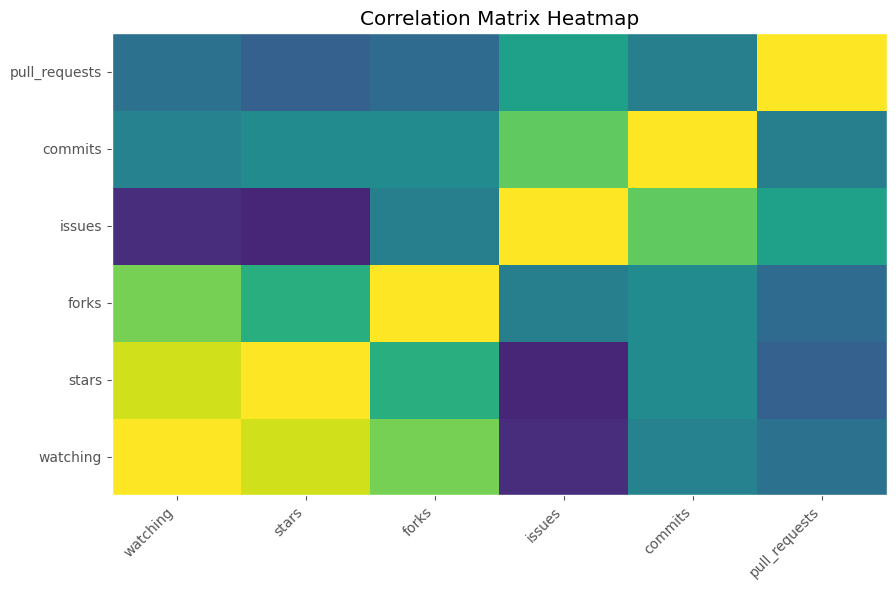

In [72]:
# your code goes here - heat map
plt.pcolor(corr,vmin=-1,vmax=1)
plt.xticks(np.arange(0.5, len(corr.columns), 1),
           corr.columns,
           rotation=45, ha='right')

plt.yticks(np.arange(0.5, len(corr.columns), 1),
           corr.columns)
plt.title("Correlation Matrix Heatmap")
plt.show()

**Your Interpretation:** TODO

We can see that the number of stars is highly related to the number of forks, which makes sense logically as popularity usually drives community cloning. The programming language is not really related to the number of commits or activity levels at all. Other factors that impact project engagement include the total number of issues and pull requests, as well as the total number of watchers.

### Task 2.1.2 Scatterplot
+ Visualize the correlations by making a scatterplot matrix.
+ Interpret what you see. Compare this to the correlation matrix. Do either provide you with insight that the other does not?

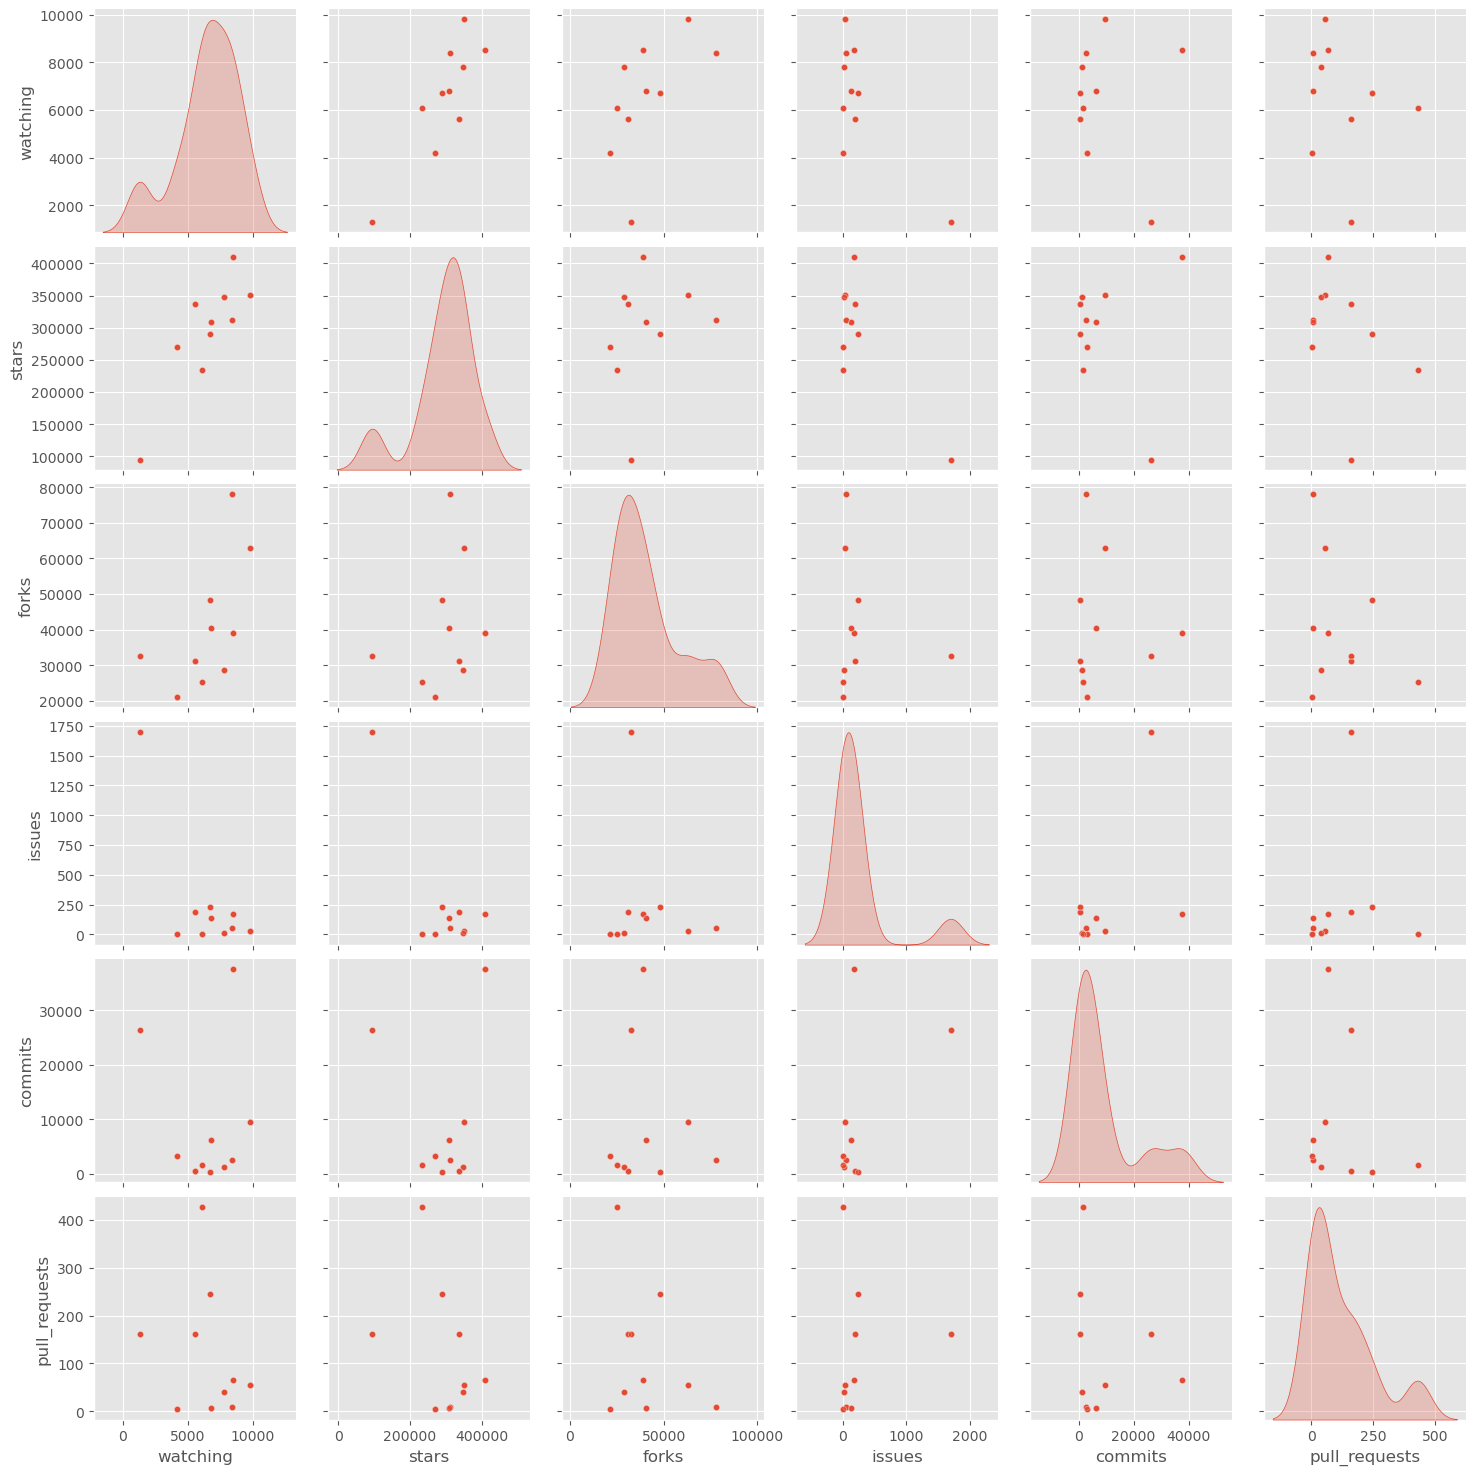

In [75]:
# your code goes here
import seaborn as sns

cols= ['watching', 'stars', 'forks', 'issues', 'commits', 'pull_requests']
sns.pairplot(num_col,
             vars=cols,
             diag_kind='kde',
             plot_kws={'alpha':0.4, 's':20})

plt.show()

**Your Interpretation:** TODO

The scatter plots are able to display outliers that's not able to be identify with the correlation matrix. The plots are also able to help us visualize the linear or nonlinear relationship between the factors. Even though we are able to how closely they are related in the correlation matrix but not the relationship.

### Task 2.2 Train/Test
+ Randomly partition the dataset into two groups, train and test, with an 80/20 split. Store these datasets, and use them for the remainder of the assignment. When you train a model, do so on the train set. When you evaluate a model, do so on the test set.




In [83]:
# your code goes here
from sklearn.model_selection import train_test_split 
y = project_info[["stars"]]
X = project_info[['watching', 'issues', 'forks', 'commits', 'pull_requests']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 2.3.1 Linear regression

+ Use linear regression to try to predict the number of Stars based on Forks, Pull Requests, and Commits. Discuss the R-squared , F-statistic p-value, MSE, and coefficient  p-values seperately for the train set AND R-squared, MSE for the test set. 
+ Interpret your results. 


In [84]:
# your code goes here
formula = "stars ~ forks + pull_requests + commits"
model = sm.ols(formula=formula, data=pd.concat([X_train, y_train], axis=1)).fit()

# 2. Get predictions for Training and Test sets
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# Display the Training Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  stars   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     6.470
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           0.000644
Time:                        15:42:22   Log-Likelihood:                -904.65
No. Observations:                  72   AIC:                             1817.
Df Residuals:                      68   BIC:                             1826.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      3.009e+05   2.84e+04     10.612

**Your Interpretation:** TODO

The model has a R2 values of .22. This mean the model is able to explain some amount of vairance in the stars column. Pull requests and commits are significant negative predictors. Forks has not influence on stars. 

### 2.3.2 Linear Regression Exploration
+ Develop a model which is simpler AND a model which is more complex than in 2.3.1, with the aim of finding a model which performs better on the test set. Hint: refer to the correlation matrix.
+ Explain why your chosen model is better than the model in 2.3.1, explain your decision-making process for generating the models, and interpret your results. 

In [85]:
# your code goes here
# More simple
formula = "stars ~ forks + commits"
model = sm.ols(formula=formula, data=pd.concat([X_train, y_train], axis=1)).fit()

# 2. Get predictions for Training and Test sets
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# Display the Training Summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  stars   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     4.028
Date:                Fri, 27 Feb 2026   Prob (F-statistic):             0.0222
Time:                        15:42:26   Log-Likelihood:                -909.71
No. Observations:                  72   AIC:                             1825.
Df Residuals:                      69   BIC:                             1832.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.476e+05   2.44e+04     10.127      0.0

In [87]:
# more complex
formula = "stars ~ forks + commits + watching + issues + pull_requests"
model = sm.ols(formula=formula, data=pd.concat([X_train, y_train], axis=1)).fit()

# 2. Get predictions for Training and Test sets
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# Display the Training Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  stars   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     82.17
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           5.52e-27
Time:                        15:42:38   Log-Likelihood:                -842.50
No. Observations:                  72   AIC:                             1697.
Df Residuals:                      66   BIC:                             1711.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       2.14e+05   2.13e+04     10.067

**Your Interpretation:** TODO

For the simpler model, I just removed the leaset informative feature pull_request based on the correlation matrix. However, the model performed worse than the baseline model. For the more complex model, I added other features espcially the one with high correlations like watching. The model performed much better with more features. It has a R2 value of 0.862.

### 2.4.1 Ridge Regression
Refer to section 6.2.1 of [ISL 2015](https://hastie.su.domains/ISLR2/ISLRv2_corrected_June_2023.pdf.download.html) for a description of ridge regression.
+ Implement ridge regression on both the variables for 2.3.1, and for your best solution from 2.3.2. 
+ Plot $\lambda$ (trained on the train set) against MSE (evaluated on the test set) in order to find an approximately optimal value. 
+ Explain your selection for $\lambda$.




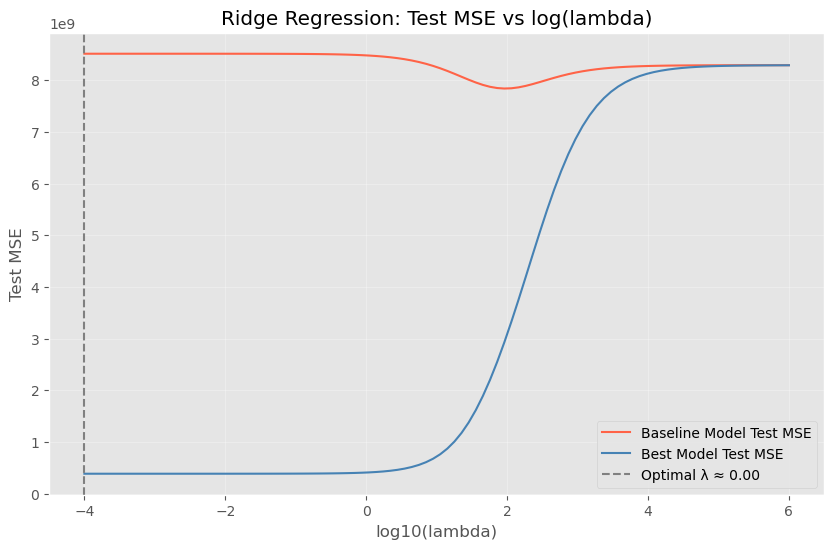

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Define features for both models
baseline_features = ['forks', 'pull_requests', 'commits']
best_features = ['forks', 'commits', 'watching', 'issues', 'pull_requests']

# Prepare data
X_train_base, X_test_base = X_train[baseline_features], X_test[baseline_features]
X_train_best, X_test_best = X_train[best_features], X_test[best_features]

# Range of lambdas
lambdas = np.logspace(-4, 6, 100)
base_test_mse = []
best_test_mse = []

for lam in lambdas:
    # Baseline Model
    ridge_base = make_pipeline(StandardScaler(), Ridge(alpha=lam))
    ridge_base.fit(X_train_base, y_train)
    base_test_mse.append(mean_squared_error(y_test, ridge_base.predict(X_test_base)))
    # Best Model
    ridge_best = make_pipeline(StandardScaler(), Ridge(alpha=lam))
    ridge_best.fit(X_train_best, y_train)
    best_test_mse.append(mean_squared_error(y_test, ridge_best.predict(X_test_best)))

# Finding the optimal lambda for the Best Model
opt_idx = np.argmin(best_test_mse)
opt_lambda = lambdas[opt_idx]
min_mse = best_test_mse[opt_idx]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(np.log10(lambdas), base_test_mse, label="Baseline Model Test MSE", color='tomato')
plt.plot(np.log10(lambdas), best_test_mse, label="Best Model Test MSE", color='steelblue')
plt.axvline(np.log10(opt_lambda), linestyle='--', color='gray', label=f'Optimal λ ≈ {opt_lambda:.2f}')
plt.xlabel("log10(lambda)")
plt.ylabel("Test MSE")
plt.title("Ridge Regression: Test MSE vs log(lambda)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Your Interpretation:** TODO

There's a significant difference between the Test MSE between the Best Model and the Baseline model. The Best Model consistently achieves a much lower error across almost the entire range of lambda. For the best model, the lambda is around 0 or smaller as the variance is manageable.

The baseline model remain with a high MSE throughout. This indicates that the baseline features were likely overfitting the training data or suffering from high variance. The best lambda is probably 2 where the dip happened and with the lowest MSE.


### 2.4.2 Lasso Regression
Refer to section 6.2.2 of [ISL 2015](https://hastie.su.domains/ISLR2/ISLRv2_corrected_June_2023.pdf.download.html) for a description of lasso regression.
+ Implement lasso regression on both the variables for 2.3.1, and for your best solution from 2.3.2. 
+ Plot $\lambda$ (trained on the train set) against MSE (evaluated on the test set) in order to find an approximately optimal value. 
+ Explain your selection for $\lambda$.




<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
C:\Users\abbyc\AppData\Local\Temp\ipykernel_26360\2780553756.py:39: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")
C:\Users\abbyc\AppData\Local\Temp\ipykernel_26360\2780553756.py:41: SyntaxWarning: invalid escape sequence '\l'
  plt.title("Lasso Regression: Test MSE vs $\lambda$")


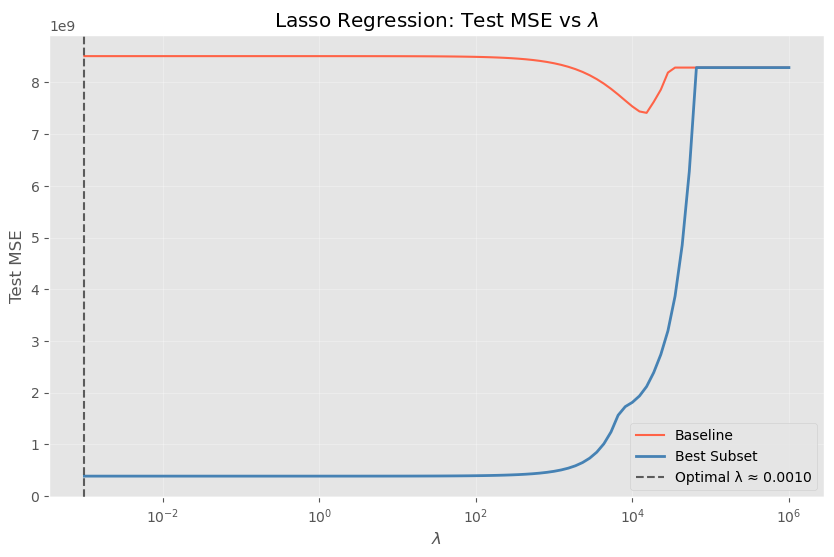

The optimal lambda for the best model is: 0.0010


In [99]:
# your code goes here
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

scaler = StandardScaler()

X_train_base_scaled = scaler.fit_transform(X_train_base)
X_test_base_scaled  = scaler.transform(X_test_base)

X_train_best_scaled = scaler.fit_transform(X_train_best)
X_test_best_scaled  = scaler.transform(X_test_best)

# setup range of ;ambdas (alphas)
lambdas = np.logspace(-3, 6, 100)
mse_base = []
mse_best = []

for lam in lambdas:
    # Lasso for baseline
    lasso_base = Lasso(alpha=lam, max_iter=10000)
    lasso_base.fit(X_train_base_scaled, y_train)
    mse_base.append(mean_squared_error(y_test, lasso_base.predict(X_test_base_scaled)))
    
    # Lasso for best
    lasso_best = Lasso(alpha=lam, max_iter=10000)
    lasso_best.fit(X_train_best_scaled, y_train)
    mse_best.append(mean_squared_error(y_test, lasso_best.predict(X_test_best_scaled)))

# 5. Find Optimal Lambda
opt_idx = np.argmin(mse_best)
opt_lambda = lambdas[opt_idx]

# 6. Plotting
plt.figure(figsize=(10, 6))
plt.semilogx(lambdas, mse_base, label="Baseline", color='tomato')
plt.semilogx(lambdas, mse_best, label="Best Subset", color='steelblue', linewidth=2)
plt.axvline(opt_lambda, color='black', linestyle='--', alpha=0.6, label=f'Optimal λ ≈ {opt_lambda:.4f}')

plt.xlabel("$\lambda$")
plt.ylabel("Test MSE")
plt.title("Lasso Regression: Test MSE vs $\lambda$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"The optimal lambda for the best model is: {opt_lambda:.4f}")

**Your Interpretation:** TODO

Suprisingly, both model had a flat line are the very begining which means that the error doesn't change much as lambda increase. After extending the lambda range to 10^4, then we can observe the MSE spikes.

### 2.5 Regression Methods Analysis
Compare the results of each regression method for this use case. Which one performed the best, and why?

**Your Interpretation:** TODO

The best model consistently performed better regardless the regularization methods. It has a very low test MSE for a range for lambda values.

### 2.6 Regression Methods Study
Based on your reading of the textbook and the prior exercises, explain the differences between linear, lasso, and ridge regression, and when you would want to use each.

**Your Interpretation:** TODO

Linear Regression is the basic approach that tries to fit everything but can easily overfit. Ridge is the "safe" version that stabilizes the model by shrinking all variables slightly, while Lasso is the "selective" version that simplifies the model by cutting out less important variables entirely.